# Прогнозирование стоимости жилой недвижимости

## Цель проекта

Построить модель, которая прогнозирует цену жилого объекта по данным из объявления.

В датасете есть характеристики объекта, его расположение, тип недвижимости и
текстовые поля с дополнительной информацией. Перед обучением модели необходимо
очистить данные, выделить полезные признаки и отделить объявления о продаже от
объявлений об аренде.

In [68]:
import numpy as np
import pandas as pd

df = pd.read_csv('data.csv')

print(f'Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} столбцов')
display(df.head(3))

Размер датасета: 377,185 строк, 18 столбцов


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"


In [69]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique': df.nunique(dropna=True)
}).sort_values(
    by=['missing_pct', 'unique'],
    ascending=[False, False]
)

display(audit)

duplicates_count = df.duplicated().sum()

print(f'Полных дубликатов: {duplicates_count:,}')
print(f'Доля полных дубликатов: {duplicates_count / len(df):.3%}')

,dtype,missing,missing_pct,unique
private pool,object,373004,98.89,1
mls-id,object,352243,93.39,24907
PrivatePool,object,336874,89.31,2
fireplace,object,274071,72.66,1652
stories,object,150716,39.96,347
baths,object,106338,28.19,229
beds,object,91282,24.20,1184
MlsId,object,66880,17.73,232944
sqft,object,40577,10.76,25405
status,object,39918,10.58,159


Полных дубликатов: 50
Доля полных дубликатов: 0.013%


### Первичные наблюдения

В датасете 377,185 объявлений и 18 исходных столбцов. Большая часть признаков имеет
текстовый тип: например, цена, площадь, число комнат и этажность записаны в разных
форматах. В данных также есть поля с высокой долей пропусков, поэтому далее потребуется
отдельная обработка признаков.

Найдено 50 полных дубликатов, что составляет 0.013% выборки. Их можно удалить до
дальнейшей обработки данных.

## Удаление дубликатов и проверка целевой переменной

Сначала удалим полные дубликаты строк. Затем проверим формат целевой переменной
`target` и статусы объявлений.

Цена хранится как текст, а часть объявлений относится к аренде. Такие строки нельзя
использовать для модели, которая прогнозирует цену продажи.

In [70]:
rows_before_dedup = len(df)

df = df.drop_duplicates().copy()

duplicates_removed = rows_before_dedup - len(df)

print(f'Строк до удаления: {rows_before_dedup:,}')
print(f'Удалено полных дубликатов: {duplicates_removed:,}')
print(f'Строк после удаления: {len(df):,}')

Строк до удаления: 377,185
Удалено полных дубликатов: 50
Строк после удаления: 377,135


In [71]:
target_text = (
    df['target']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

status_text = (
    df['status']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

is_rent_status = status_text.str.contains(r'\brent\b', regex=True)
is_monthly_rent = target_text.str.contains(r'/mo\b', regex=True)
is_rent = is_rent_status | is_monthly_rent

print(f'Пропусков в target: {df["target"].isna().sum():,}')
print(f'Цен с пометкой /mo: {is_monthly_rent.sum():,}')
print(f'Объявлений со статусом аренды: {is_rent_status.sum():,}')
print(f'Всего объявлений, исключаемых как аренда: {is_rent.sum():,}')

Пропусков в target: 2,480
Цен с пометкой /mo: 398
Объявлений со статусом аренды: 412
Всего объявлений, исключаемых как аренда: 412


In [72]:
RANDOM_STATE=42

sample_size = min(20, df['target'].notna().sum())

print('Примеры значений target:')
display(
    df.loc[df['target'].notna(), ['target', 'status']]
    .sample(n=sample_size, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print('Примеры объявлений об аренде:')
display(
    df.loc[is_rent, ['status', 'target']]
    .head(10)
)

Примеры значений target:


,target,status
0,"$69,500",Active
1,"$519,000",for sale
2,"$325,000",for sale
3,"$302,990",Active
4,"$829,000",For sale
5,"$749,888",New construction
6,"$409,999",for sale
7,"$217,580",for sale
8,"$229,000",for sale
9,"$299,000",NaN


Примеры объявлений об аренде:


,status,target
547,for rent,"$5,500/mo"
609,for rent,"$10,500/mo"
2075,for rent,"$6,390/mo"
3025,for rent,"$1,200/mo"
3645,for rent,"$3,600/mo"
4613,for rent,"$5,500/mo"
5515,for rent,"$1,200/mo"
5873,Apartment for rent,"$1,250"
6837,for rent,"$1,200/mo"
8167,for rent,"$3,250/mo"


### Вывод

После удаления полных дубликатов осталось 377,135 строк. Поле `target` содержит
значения в разных текстовых форматах: с символом `$`, разделителями тысяч, знаком `+`
и без обозначения валюты.

В датасете есть объявления об аренде. Они определяются по слову `rent` в поле `status`
или по маркеру `/mo` в цене. Эти объявления будут исключены, потому что далее модель
будет прогнозировать цену продажи жилого объекта.

## Очистка целевой переменной

Целевая переменная `target` хранит цену в текстовом формате. Преобразуем её в число и
оставим только объявления о продаже.

Из выборки исключаются:

- объявления об аренде;
- строки, где цена не распозналась;
- цены ниже $1,000.

Объекты с ценой ровно $1,000 сохраняются. Среди них есть foreclosure-объявления, то
есть это может быть реальный, хотя и специфический сегмент рынка.

In [73]:
df['price'] = pd.to_numeric(
    target_text.str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

MIN_SALE_PRICE = 1_000

sales_mask = (
    ~is_rent
    & df['price'].notna()
    & df['price'].ge(MIN_SALE_PRICE)
)

sales_df = df.loc[sales_mask].copy()

print(f'Всего строк после удаления дубликатов: {len(df):,}')
print(f'Исключено объявлений об аренде: {is_rent.sum():,}')
print(f'Строк без распознанной цены: {df["price"].isna().sum():,}')
print(
    f'Строк с ценой ниже ${MIN_SALE_PRICE:,}: '
    f'{df["price"].lt(MIN_SALE_PRICE).sum():,}'
)
print(f'Осталось объявлений о продаже: {len(sales_df):,}')

display(
    sales_df['price']
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .to_frame('price')
)

Всего строк после удаления дубликатов: 377,135
Исключено объявлений об аренде: 412
Строк без распознанной цены: 2,480
Строк с ценой ниже $1,000: 101
Осталось объявлений о продаже: 374,167


,price
count,3.741670e+05
mean,6.455644e+05
std,1.842441e+06
min,1.000000e+03
1%,7.500000e+03
5%,3.790000e+04
25%,1.879900e+05
50%,3.200000e+05
75%,5.849000e+05
95%,1.950000e+06


In [74]:
display_columns = [
    'price', 'propertyType', 'city', 'state', 'zipcode',
    'sqft', 'beds', 'baths', 'status'
]

print('Самые дешёвые объекты:')
display(sales_df[display_columns].nsmallest(20, 'price'))

print('Самые дорогие объекты:')
display(sales_df[display_columns].nlargest(20, 'price'))

Самые дешёвые объекты:


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
1357,1000.0,single-family home,Detroit,MI,48206,"2,544 sqft",6 Beds,2 Baths,foreclosure
1682,1000.0,Single Family,Detroit,MI,48219,"1,572 sqft",4,2.0,NaN
2282,1000.0,single-family home,Detroit,MI,48205,"2,048 sqft",4 Beds,2 Baths,foreclosure
2644,1000.0,single-family home,Detroit,MI,48227,"1,827 sqft",4 Beds,2 Baths,foreclosure
2673,1000.0,NaN,Memphis,TN,38106,NaN,NaN,NaN,Active
2923,1000.0,single-family home,Detroit,MI,48205,921 sqft,3 Beds,NaN,foreclosure
3049,1000.0,single-family home,Detroit,MI,48213,"1,386 sqft",3 Beds,2 Baths,foreclosure
3239,1000.0,single-family home,Detroit,MI,48204,"1,984 sqft",4 Beds,2 Baths,foreclosure
3380,1000.0,NaN,Memphis,TN,38108,NaN,NaN,NaN,Active
3616,1000.0,single-family home,Detroit,MI,48234,687 sqft,3 Beds,NaN,foreclosure


Самые дорогие объекты:


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
132425,195000000.0,Single Family,Los Angeles,CA,90077,--,11,18.0,For sale
143528,165000000.0,single-family home,Beverly Hills,CA,90210,"28,660 sqft",20 Beds,23 Baths,for sale
285993,165000000.0,Single Family,Beverly Hills,CA,90210,"28,660",20,23.0,For sale
110083,150000000.0,single-family home,Los Angeles,CA,90077,NaN,NaN,NaN,for sale
178931,129000000.0,Single Family,Beverly Hills,CA,90210,"43,000",12,23.0,For sale
119862,115000000.0,Single Family,Los Angeles,CA,90077,"12,201",9,10.0,For sale
294206,115000000.0,single-family home,Los Angeles,CA,90077,"12,201 sqft",9 Beds,10 Baths,for sale
54164,110000000.0,single-family home,Beverly Hills,CA,90210,"38,000 sqft",12 Beds,24 Baths,for sale
354264,110000000.0,lot/land,Beverly Hills,CA,90210,741 sqft,NaN,NaN,for sale
151594,98000000.0,Condo,New York,NY,10016,"19,815",11,14,For sale


Минимальные цены в основном встречаются у foreclosure-объявлений в Detroit, поэтому
значения $1,000 не удаляются автоматически. Максимальные цены относятся к дорогим
объектам в California и New York. Эти наблюдения редкие, но выглядят правдоподобно,
поэтому они остаются в данных.

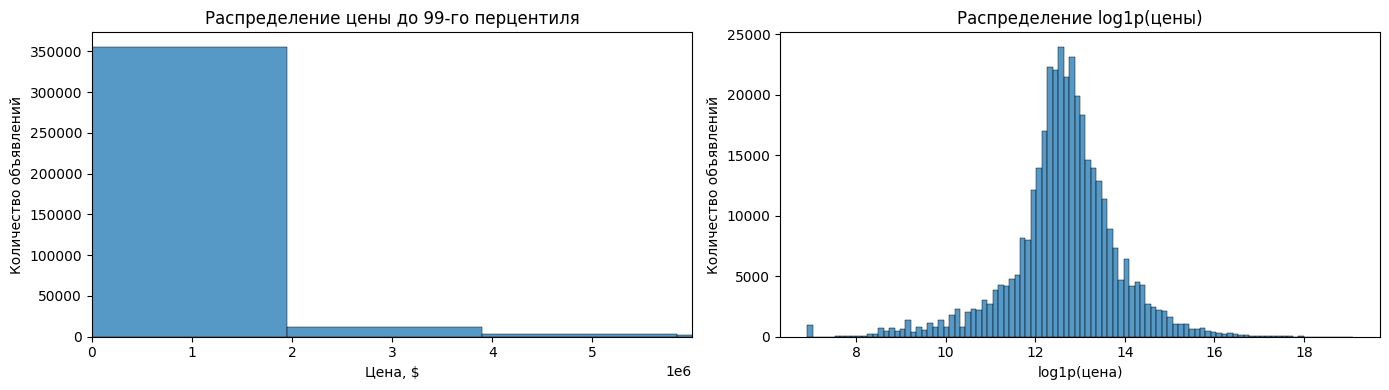

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_df['log_price'] = np.log1p(sales_df['price'])

price_p99 = sales_df['price'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=sales_df, x='price', bins=100, ax=axes[0])
axes[0].set_xlim(0, price_p99)
axes[0].set_title('Распределение цены до 99-го перцентиля')
axes[0].set_xlabel('Цена, $')
axes[0].set_ylabel('Количество объявлений')

sns.histplot(data=sales_df, x='log_price', bins=100, ax=axes[1])
axes[1].set_title('Распределение log1p(цены)')
axes[1].set_xlabel('log1p(цена)')
axes[1].set_ylabel('Количество объявлений')

plt.tight_layout()
plt.show()

### Вывод

Цена имеет выраженный правый хвост: медианная стоимость объекта составляет $320,000,
а средняя — около $645,564. Среднее значение заметно выше медианы из-за небольшого
числа очень дорогих объектов.

Для обучения будет использоваться `log_price = log1p(price)`. Логарифмирование
уменьшает влияние дорогих объектов на обучение. При оценке качества прогнозы будут
переводиться обратно в доллары с помощью `np.expm1`.

## Числовые признаки

Поля `sqft`, `beds`, `baths` и `stories` записаны в разных текстовых форматах:
встречаются единицы измерения, подписи, разделители тысяч и пропуски.

Из каждого поля извлекается отдельный числовой признак. Нераспознанные значения
остаются пропусками. Явные ошибки парсинга будут заменены на `NaN`, а сами строки
не будут удаляться.

In [76]:
import re

def normalize_numeric_text(value) -> str:
    """Приводит значение к удобному для парсинга виду."""
    if pd.isna(value):
        return ''

    return str(value).strip().lower().replace(',', '')

def parse_sqft(value) -> float:
    """Извлекает площадь объекта в квадратных футах."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:sq\.?\s*ft\.?|sqft)',
        r'(\d+(?:\.\d+)?)\s*$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan

def parse_beds(value) -> float:
    """Извлекает количество спален."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none', 'studio'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:beds?|bd)\b',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan

def parse_baths(value) -> float:
    """Извлекает количество ванных комнат."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:baths?|ba)\b',
        r'(?:bathrooms?\s*:?\s*)(\d+(?:\.\d+)?)',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan

def parse_stories(value) -> float:
    """Извлекает количество этажей."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none', 'studio'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:stories|story|storeys|storey)\b',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan

In [77]:
sales_df['sqft_num'] = sales_df['sqft'].apply(parse_sqft)
sales_df['beds_num'] = sales_df['beds'].apply(parse_beds)
sales_df['baths_num'] = sales_df['baths'].apply(parse_baths)
sales_df['stories_num'] = sales_df['stories'].apply(parse_stories)

numeric_columns = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num'
]


def make_numeric_report(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Возвращает краткую сводку по числовым признакам."""
    return pd.DataFrame({
        'missing_pct': frame[columns].isna().mean().mul(100).round(2),
        'min': frame[columns].min(),
        'median': frame[columns].median(),
        'max': frame[columns].max()
    })


display(make_numeric_report(sales_df, numeric_columns))

,missing_pct,min,median,max
sqft_num,10.92,0.0,1800.0,795979430.0
beds_num,29.67,0.0,3.0,144.0
baths_num,28.78,0.0,2.5,5000.0
stories_num,43.62,0.0,2.0,1120.0


In [78]:
parse_check_columns = [
    'sqft', 'sqft_num',
    'beds', 'beds_num',
    'baths', 'baths_num',
    'stories', 'stories_num'
]

display(
    sales_df[parse_check_columns]
    .sample(n=15, random_state=RANDOM_STATE)
)

,sqft,sqft_num,beds,beds_num,baths,baths_num,stories,stories_num
63455,629,629.0,1,1.0,1.0,1.0,NaN,NaN
42624,"2,926",2926.0,3,3.0,3.0,3.0,1.0,1.0
67147,"1,289",1289.0,NaN,NaN,NaN,NaN,NaN,NaN
251662,1716,1716.0,3,3.0,2,2.0,NaN,NaN
354373,"1,930",1930.0,Baths,NaN,Sq. Ft.,NaN,NaN,NaN
368370,"1,635 sqft",1635.0,NaN,NaN,NaN,NaN,1.0,1.0
265594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
293289,1380,1380.0,2.0,2.0,2.5,2.5,Townhouse,NaN
254408,"Total interior livable area: 4,699 sqft",4699.0,5 bd,5.0,Bathrooms: 5,5.0,NaN,NaN
306623,"3,512",3512.0,4,4.0,4.0,4.0,2.0,2.0


### Контроль подозрительных значений

Для числовых признаков задаются широкие границы. Значения за их пределами чаще всего
связаны с ошибками формата или ошибочным извлечением числа из текста. Они заменяются
на `NaN`, но сами объявления сохраняются.

In [79]:
valid_ranges = {
    'sqft_num': (100, 100_000),
    'beds_num': (0, 60),
    'baths_num': (0.5, 60),
    'stories_num': (1, 50)
}

invalid_counts = {}

for column, (lower_bound, upper_bound) in valid_ranges.items():
    invalid_mask = (
        sales_df[column].notna()
        & ~sales_df[column].between(lower_bound, upper_bound)
    )

    invalid_counts[column] = invalid_mask.sum()
    sales_df.loc[invalid_mask, column] = np.nan

invalid_report = pd.Series(
    invalid_counts,
    name='invalid_values'
).to_frame()

display(invalid_report)
display(make_numeric_report(sales_df, numeric_columns))

,invalid_values
sqft_num,12691
beds_num,51
baths_num,18442
stories_num,11569


,missing_pct,min,median,max
sqft_num,14.31,100.0,1839.0,100000.0
beds_num,29.68,0.0,3.0,53.0
baths_num,33.71,0.5,2.5,60.0
stories_num,46.71,1.0,2.0,50.0


In [80]:
inspection_columns = [
    'price', 'propertyType', 'city', 'state',
    'sqft', 'beds', 'baths', 'stories'
]

for column in numeric_columns:
    print(f'\n{column}: минимальные и максимальные значения после очистки')

    display(
        pd.concat([
            sales_df.loc[
                sales_df[column].notna(),
                [column] + inspection_columns
            ].nsmallest(3, column),
            sales_df.loc[
                sales_df[column].notna(),
                [column] + inspection_columns
            ].nlargest(3, column)
        ])
    )


sqft_num: минимальные и максимальные значения после очистки


,sqft_num,price,propertyType,city,state,sqft,beds,baths,stories
9261,100.0,789000.0,lot/land,Saint Johns,FL,100 sqft,NaN,NaN,NaN
62267,100.0,400000.0,Miscellaneous,Miami,FL,100 sqft,0,NaN,NaN
121653,100.0,700000.0,lot/land,Brooksville,FL,100 sqft,2 Beds,2 Baths,1.0
173711,100000.0,410000.0,coop,Brooklyn,NY,"100,000 sqft",NaN,NaN,NaN
63514,99999.0,1600000.0,Multi-Family Home,Madison,TN,99999,NaN,116 / 116 / 116,2.00
350352,99999.0,1600000.0,lot/land,Madison,TN,"99,999 sqft",NaN,NaN,NaN



beds_num: минимальные и максимальные значения после очистки


,beds_num,price,propertyType,city,state,sqft,beds,baths,stories
496,0.0,85000.0,Condo/Townhome/Row Home/Co-Op,Phoenix,AZ,429,0,1,1
966,0.0,279000.0,Multi-Family Home,Washington,DC,1184,0,NaN,NaN
1486,0.0,149900.0,Condo,Fort Lauderdale,FL,582,0,1.0,5.0
166312,53.0,11500000.0,multi-family,Encino,CA,"29,536 sqft",53 Beds,36 Baths,2.0
280333,52.0,6360000.0,multi-family,Los Angeles,CA,"29,096 sqft",52 Beds,40 Baths,3.0
175804,51.0,1999500.0,lot/land,Kissimmee,FL,"47,760 sqft",51 Beds,NaN,NaN



baths_num: минимальные и максимальные значения после очистки


,baths_num,price,propertyType,city,state,sqft,beds,baths,stories
125410,0.50,159000.0,lot/land,Panama City Beach,FL,460 sqft,NaN,0.5 Baths,NaN
129480,0.75,725000.0,single-family home,Seattle,WA,"1,110 sqft",2 Beds,0.75 Baths,1.0
237230,0.75,394900.0,condo,Des Moines,WA,815 sqft,NaN,0.75 Baths,2.0
307232,60.00,900000.0,multi-family,Detroit,MI,"18,192 sqft",NaN,60 Baths,3.0
110423,55.00,30000000.0,Multi Family,Boston,MA,"30,500",99,55.0,NaN
122038,44.00,20000000.0,multi-family,Boston,MA,"21,210 sqft",78 Beds,44 Baths,NaN



stories_num: минимальные и максимальные значения после очистки


,stories_num,price,propertyType,city,state,sqft,beds,baths,stories
2,1.0,2895000.0,single-family home,Los Angeles,CA,"3,000 sqft",3 Beds,2 Baths,1.0
12,1.0,525000.0,single-family home,Pembroke Pines,FL,"2,839 sqft",4 Beds,3 Baths,1.0
13,1.0,499900.0,Single Family,Eugene,OR,"Total interior livable area: 1,820 sqft",3 bd,Bathrooms: 2,1.0
74734,50.0,1795000.0,condo,New York,NY,NaN,2 Beds,2 Baths,50
220384,50.0,1050000.0,condo,New York,NY,600 sqft,NaN,NaN,50
366538,50.0,3950000.0,Condo,Miami,FL,"Total interior livable area: 4,030 sqft",3 bd,Bathrooms: 4,50.0


### Вывод

Из текстовых полей извлечены площадь, количество спален, ванных комнат и этажей.
Парсеры корректно обрабатывают распространённые форматы: например, `3 Beds`,
`Bathrooms: 2`, `1,947 sqft` и `Total interior livable area: 4,699 sqft`.

В данных встречались нулевые и нереалистично большие значения. Значения за заданными
широкими границами заменены на `NaN`, но строки сохранены. Для крупных объектов
значения на верхних границах могут быть реальными, поэтому границы использовались
только для отсева явных ошибок парсинга.

Числовые пропуски пока не заполняются. Для Ridge они будут обработаны внутри
`Pipeline`, обученного только на train-выборке. CatBoost будет получать числовые
`NaN` напрямую.

## Тип недвижимости

В `propertyType` содержится много вариантов написания одного и того же типа жилья:
например, `single-family home`, `single family` и `Single Family Home`. Кроме типов
объектов, в поле встречаются стили зданий и смешанные категории.

Для модели объединим исходные значения в несколько более крупных групп. Это уменьшит
число редких категорий и сделает признак устойчивее.

Земельные участки будут исключены отдельно: они не относятся к жилой недвижимости, а
для оценки их стоимости нужны другие признаки, например площадь участка и разрешённое
назначение земли.

In [81]:
# Нормализация исходного признака propertyType.

property_type = (
    sales_df['propertyType']
    .fillna('missing')
    .astype(str)
    .str.strip()
    .str.lower()
)

print(f'Уникальных значений propertyType: {property_type.nunique():,}')

display(
    property_type
    .value_counts()
    .head(30)
    .to_frame('listings')
)

Уникальных значений propertyType: 1,272


,listings
propertyType,
single-family home,91150
single family,61884
condo,42358
missing,34538
single family home,31724
lot/land,20467
townhouse,18297
land,10928
multi-family,7762


In [82]:
def group_property_type(value: str) -> str:
    """Объединяет исходные типы недвижимости в крупные группы."""
    text = str(value).strip().lower()

    if text in {'', 'missing', 'nan', 'none'}:
        return 'missing'

    if re.search(r'\b(?:land|lot)\b', text):
        return 'land'

    if any(token in text for token in ['condo', 'coop', 'co-op', 'high rise']):
        return 'condo_coop'

    if 'town' in text or 'row home' in text:
        return 'townhouse'

    if any(token in text for token in ['multi', 'duplex', 'triplex', 'fourplex']):
        return 'multi_family'

    if 'mobile' in text or 'manufactured' in text:
        return 'mobile_manufactured'

    if 'apartment' in text:
        return 'apartment'

    if any(
        token in text
        for token in [
            'single',
            'detached',
            'ranch',
            'colonial',
            'traditional',
            'contemporary',
            'one story',
            'two story'
        ]
    ):
        return 'single_family'

    return 'other'

In [83]:
sales_df['property_group'] = property_type.apply(group_property_type)

property_summary = (
    sales_df
    .groupby('property_group')
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median'),
        mean_price=('price', 'mean')
    )
    .sort_values('listings', ascending=False)
)

property_summary['share_pct'] = (
    property_summary['listings'] / len(sales_df) * 100
).round(2)

display(property_summary)

,listings,median_price,mean_price,share_pct
property_group,,,,
single_family,206398,334990.0,609662.845318,55.16
condo_coop,57122,375000.0,821800.831466,15.27
missing,34662,310000.0,860066.595407,9.26
land,31458,73000.0,316776.278784,8.41
townhouse,18480,319994.0,576174.586472,4.94
multi_family,12540,599000.0,953746.691148,3.35
other,9138,320000.0,565140.803677,2.44
mobile_manufactured,3560,99500.0,125224.073876,0.95
apartment,809,550000.0,962028.862794,0.22


In [84]:
land_count = sales_df['property_group'].eq('land').sum()
land_share = land_count / len(sales_df) * 100

sales_df = sales_df.loc[
    sales_df['property_group'].ne('land')
].copy()

print(f'Исключено земельных участков: {land_count:,} ({land_share:.2f}%)')
print(f'Размер выборки после фильтрации: {sales_df.shape[0]:,} строк')

Исключено земельных участков: 31,458 (8.41%)
Размер выборки после фильтрации: 342,709 строк


### Вывод

Исходный признак `propertyType` содержит 1,272 варианта. После группировки объекты
разделены на категории `single_family`, `condo_coop`, `townhouse`, `multi_family`,
`mobile_manufactured`, `apartment`, `other` и `missing`.

В группу `land` вошли 31,458 объявлений, или 8.41% выборки. Их медианная цена равна
$73,000, тогда как у основной жилой категории `single_family` она составляет
$334,990. Земельные участки исключены, поскольку относятся к другой задаче
ценообразования.

Признак `property_group` будет использоваться в модели как категориальный.

## Географические признаки

Цена жилья зависит от расположения объекта. В модели будут использоваться штат,
город и ZIP-код.

Сначала проверим пропуски и число уникальных значений. Затем сравним медианные цены
в штатах с наибольшим количеством объявлений.

In [85]:
geo_columns = ['state', 'city', 'zipcode']

geo_report = pd.DataFrame({
    'missing': sales_df[geo_columns].isna().sum(),
    'missing_pct': sales_df[geo_columns].isna().mean().mul(100).round(3),
    'unique': sales_df[geo_columns].nunique(dropna=True)
})

display(geo_report)

print('Топ-10 штатов по числу объявлений:')
display(sales_df['state'].value_counts().head(10).to_frame('listings'))

print('Топ-10 городов по числу объявлений:')
display(sales_df['city'].value_counts().head(10).to_frame('listings'))

,missing,missing_pct,unique
state,0,0.000,38
city,9,0.003,1908
zipcode,0,0.000,4469


Топ-10 штатов по числу объявлений:


,listings
state,
FL,101997
TX,77916
NY,23866
CA,22151
NC,18886
TN,15832
WA,12526
OH,11495
IL,8179


Топ-10 городов по числу объявлений:


,listings
city,
Houston,23278
Miami,15244
San Antonio,15018
Jacksonville,9467
Dallas,8399
Brooklyn,7183
New York,6902
Chicago,6327
Charlotte,6075


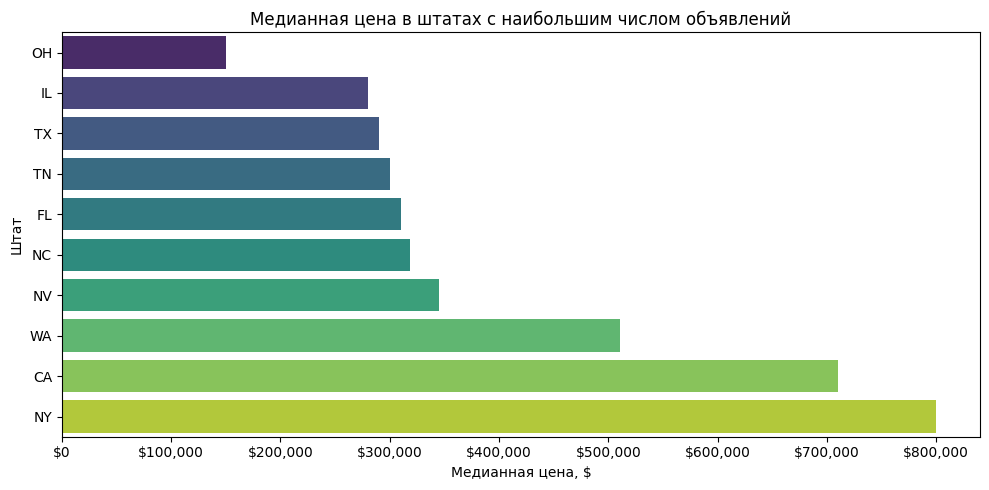

,state,listings,median_price
0,OH,11495,149900.0
1,IL,8179,279900.0
2,TX,77916,290000.0
3,TN,15832,299900.0
4,FL,101997,309900.0
5,NC,18886,319000.0
6,NV,7642,345000.0
7,WA,12526,510990.0
8,CA,22151,710000.0
9,NY,23866,800000.0


In [86]:
from matplotlib.ticker import StrMethodFormatter

top_states = sales_df['state'].value_counts().head(10).index

state_stats = (
    sales_df.loc[sales_df['state'].isin(top_states)]
    .groupby('state')
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median')
    )
    .sort_values('median_price')
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=state_stats,
    x='median_price',
    y='state',
    hue='state',
    legend=False,
    palette='viridis'
)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title('Медианная цена в штатах с наибольшим числом объявлений')
plt.xlabel('Медианная цена, $')
plt.ylabel('Штат')
plt.tight_layout()
plt.show()

display(state_stats)

### Вывод

В десяти штатах с наибольшим числом объявлений медианная цена отличается более чем
в пять раз: от $149,900 в Ohio до $800,000 в New York. Значит, расположение объекта
содержит важную информацию для прогноза цены.

Признаки `state`, `city` и `zipcode` будут использоваться как категориальные. Несмотря
на числовой вид ZIP-кода, его значение является идентификатором территории, а не
числовой величиной с линейным смыслом.

## Бассейн и камин

Информация о бассейне и камине хранится в текстовых полях и часто отсутствует.
На её основе создаются бинарные признаки.

Для бассейна объединяются два исходных столбца: `PrivatePool` и `private pool`.
Для камина дополнительно сохраняется отдельный признак пропуска, потому что пустое
значение в объявлении не означает, что камина точно нет.

In [87]:
pool_text = (
    sales_df['PrivatePool']
    .combine_first(sales_df['private pool'])
    .astype('string')
    .str.strip()
    .str.lower()
)

sales_df['has_pool'] = pool_text.isin(
    {'yes', 'true', '1'}
).astype('int8')


fireplace_text = (
    sales_df['fireplace']
    .astype('string')
    .str.strip()
    .str.lower()
)

no_fireplace_values = {
    '0', 'no', 'none', 'nan', 'not applicable', 'false'
}

sales_df['fireplace_missing'] = fireplace_text.isna().astype('int8')

sales_df['has_fireplace'] = (
    fireplace_text.notna()
    & ~fireplace_text.isin(no_fireplace_values)
).astype('int8')

In [88]:
# Контроль распределения сформированных бинарных признаков.
binary_features = [
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

binary_report = pd.DataFrame({
    'count_0': [(sales_df[col] == 0).sum() for col in binary_features],
    'count_1': [(sales_df[col] == 1).sum() for col in binary_features],
    'share_1_pct': [
        round(sales_df[col].mean() * 100, 2)
        for col in binary_features
    ]
}, index=binary_features)

display(binary_report)

,count_0,count_1,share_1_pct
has_pool,298863,43846,12.79
has_fireplace,243831,98878,28.85
fireplace_missing,101403,241306,70.41


### Вывод

Признак `has_pool` равен 1 у 12.79% объектов, а `has_fireplace` — у 28.85%.

В 70.41% объявлений поле `fireplace` не заполнено. Поэтому в модель добавлен
`fireplace_missing`: он позволяет отличить отсутствие информации от явного указания,
что камина нет. Значение `has_fireplace = 0` означает, что наличие камина не
подтверждено.

## Год постройки

В поле `homeFacts` хранится дополнительная информация об объекте. Из него извлекается
год постройки.

Также создаётся признак `year_built_missing`. Пропуск года может быть полезной
информацией для модели: объявления с незаполненными характеристиками могут отличаться
от полностью заполненных.

Возраст объекта не рассчитывается, так как в датасете нет даты публикации объявления.

In [89]:
import ast


def extract_fact(value, label: str):
    """Возвращает значение характеристики из поля homeFacts."""
    if pd.isna(value):
        return np.nan

    try:
        facts_data = ast.literal_eval(value)

        for fact in facts_data.get('atAGlanceFacts', []):
            fact_label = str(
                fact.get('factLabel', '')
            ).strip().lower()

            if fact_label == label.lower():
                fact_value = fact.get('factValue')

                if fact_value in {None, '', 'None'}:
                    return np.nan

                return fact_value

    except (ValueError, SyntaxError, TypeError, AttributeError):
        return np.nan

    return np.nan


sales_df['year_built'] = pd.to_numeric(
    sales_df['homeFacts'].apply(
        lambda value: extract_fact(value, 'Year built')
    ),
    errors='coerce'
)

MIN_VALID_YEAR = 1600
MAX_VALID_YEAR = 2026

invalid_year_mask = (
    sales_df['year_built'].notna()
    & ~sales_df['year_built'].between(
        MIN_VALID_YEAR,
        MAX_VALID_YEAR
    )
)

invalid_year_count = invalid_year_mask.sum()

sales_df.loc[invalid_year_mask, 'year_built'] = np.nan

sales_df['year_built_missing'] = (
    sales_df['year_built']
    .isna()
    .astype('int8')
)

print(f'Допустимый диапазон года постройки: {MIN_VALID_YEAR}–{MAX_VALID_YEAR}')
print(f'Некорректных значений: {invalid_year_count:,}')
print(f'Доля пропусков: {sales_df["year_built"].isna().mean():.2%}')

display(
    sales_df[['year_built', 'year_built_missing']]
    .describe()
)

Допустимый диапазон года постройки: 1600–2026
Некорректных значений: 6
Доля пропусков: 10.58%


,year_built,year_built_missing
count,306459.000000,342709.000000
mean,1979.658669,0.105775
std,33.466723,0.307550
min,1703.000000,0.000000
25%,1957.000000,0.000000
50%,1985.000000,0.000000
75%,2007.000000,0.000000
max,2025.000000,1.000000


### Вывод

Год постройки извлечён для 306,459 объектов. У 10.58% объявлений год не указан,
поэтому в модель будут передаваться два признака: `year_built` и
`year_built_missing`.

После проверки диапазона шесть некорректных значений заменены на `NaN`. Медианный год
постройки — 1985, а корректные значения лежат в диапазоне от 1703 до 2025 года.

## Связь числовых признаков с ценой

Проверим, как площадь, число комнат, этажность и год постройки связаны с ценой.

Используется корреляция Спирмена, потому что она оценивает монотонную связь и менее
чувствительна к выбросам, чем корреляция Пирсона. Анализ проводится для `log_price`,
так как распределение исходной цены имеет длинный правый хвост.

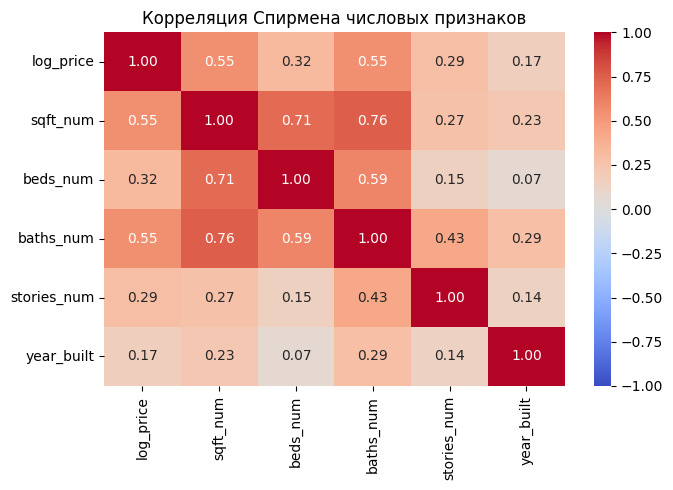

In [90]:
numeric_eda_features = [
    'log_price',
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'year_built'
]

spearman_matrix = sales_df[numeric_eda_features].corr(method='spearman')

plt.figure(figsize=(7, 5))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Корреляция Спирмена числовых признаков')
plt.tight_layout()
plt.show()

In [91]:
from scipy.stats import spearmanr

spearman_test_rows = []

for feature in numeric_eda_features:
    if feature == 'log_price':
        continue

    pair = sales_df[[feature, 'log_price']].dropna()

    rho, p_value = spearmanr(
        pair[feature],
        pair['log_price']
    )

    spearman_test_rows.append({
        'feature': feature,
        'n_pairs': len(pair),
        'spearman_rho': rho,
        'p_value': p_value
    })

spearman_tests = (
    pd.DataFrame(spearman_test_rows)
    .sort_values('spearman_rho', ascending=False)
    .reset_index(drop=True)
)

display(spearman_tests)

,feature,n_pairs,spearman_rho,p_value
0,baths_num,247452,0.554598,0.0
1,sqft_num,316626,0.553707,0.0
2,beds_num,260577,0.319066,0.0
3,stories_num,197448,0.290203,0.0
4,year_built,306459,0.167661,0.0


Во всех тестах p-value отображается как `0.0` из-за очень большого размера выборки.
Это означает, что значение p-value крайне мало; далее его интерпретируем как
\(p < 0.001\).

### Вывод

Для всех числовых признаков получены статистически значимые положительные связи с
`log_price` (\(p < 0.001\)).

Наиболее сильная связь наблюдается у числа ванных комнат
(`baths_num`, \(\rho = 0.555\)) и площади (`sqft_num`, \(\rho = 0.554\)).
Количество спален (`beds_num`, \(\rho = 0.319\)) и этажей
(`stories_num`, \(\rho = 0.290\)) связано с ценой слабее. У года постройки связь
слабая, но положительная (`year_built`, \(\rho = 0.168\)): более новые объекты в
среднем стоят дороже.

Корреляция не доказывает причинную связь и не показывает взаимодействия признаков.
Например, влияние площади может различаться между штатами, городами и типами
недвижимости. Такие нелинейные зависимости будут учитывать модели Ridge и CatBoost.

## Различия цен между типами недвижимости

Проверим, различается ли распределение `log_price` между группами `property_group`.

Нулевая гипотеза \(H_0\): распределения `log_price` одинаковы для всех групп.

Альтернативная гипотеза \(H_1\): хотя бы для одной группы распределение `log_price`
отличается.

Уровень значимости: \(\alpha = 0.05\).

Для проверки используется критерий Kruskal–Wallis. Он подходит для сравнения нескольких
независимых групп и не требует нормального распределения признака в каждой из них.

In [92]:
from scipy.stats import kruskal

property_groups = (
    sales_df.loc[
        sales_df['property_group'].ne('missing'),
        ['property_group', 'log_price']
    ]
    .dropna()
)

groups = [
    group['log_price'].to_numpy()
    for _, group in property_groups.groupby('property_group')
]

kruskal_stat, kruskal_p_value = kruskal(*groups)

group_summary = (
    property_groups
    .groupby('property_group')
    .agg(
        listings=('log_price', 'size'),
        median_log_price=('log_price', 'median')
    )
    .sort_values('listings', ascending=False)
)

print(f'Статистика Kruskal–Wallis: {kruskal_stat:.2f}')
print(f'p-value: {kruskal_p_value:.3e}')

display(group_summary)

Статистика Kruskal–Wallis: 9167.71
p-value: 0.000e+00


,listings,median_log_price
property_group,,
single_family,206398,12.721859
condo_coop,57122,12.834684
townhouse,18480,12.676061
multi_family,12540,13.303019
other,9138,12.676079
mobile_manufactured,3560,11.507923
apartment,809,13.217675


### Вывод

Тест Kruskal–Wallis показал статистически значимые различия в распределении `log_price`
между группами типов недвижимости: \(H = ...\), \(p < 0.001\). При уровне значимости
\(\alpha = 0.05\) нулевая гипотеза отвергается.

Различия видны и по медианным значениям. Наименьшая медианная логарифмическая цена
наблюдается у `mobile_manufactured`, а наиболее высокие значения — у `multi_family`
и `apartment`.

Размер выборки очень большой, поэтому одного p-value недостаточно для практического
вывода. Здесь различия подтверждаются не только тестом, но и заметной разницей
медианных цен. Поэтому `property_group` сохраняется в итоговом наборе признаков как
категориальный признак.

## Итоговый набор признаков

Для модели используются характеристики объекта, его тип и расположение.

Числовые признаки: площадь, число спален, ванных комнат и этажей, год постройки,
а также бинарные признаки бассейна, камина и пропусков.

Категориальные признаки: группа типа недвижимости, штат, город и ZIP-код.

In [93]:
categorical_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]

for column in categorical_features:
    sales_df[column] = (
        sales_df[column]
        .fillna('missing')
        .astype(str)
        .str.strip()
        .replace('', 'missing')
    )

numeric_features = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'year_built',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

feature_cols = numeric_features + categorical_features

print('Пропуски в категориальных признаках:')
display(
    sales_df[categorical_features]
    .isna()
    .sum()
    .to_frame('missing')
)

Пропуски в категориальных признаках:


,missing
property_group,0
state,0
city,0
zipcode,0


In [94]:
feature_report = pd.DataFrame({
    'dtype': sales_df[feature_cols].dtypes.astype(str),
    'missing': sales_df[feature_cols].isna().sum(),
    'missing_pct': sales_df[feature_cols].isna().mean().mul(100).round(2),
    'unique': sales_df[feature_cols].nunique(dropna=True)
})

display(feature_report)

,dtype,missing,missing_pct,unique
sqft_num,float64,26083,7.61,9056
beds_num,float64,82132,23.97,46
baths_num,float64,95257,27.80,72
stories_num,float64,145261,42.39,58
year_built,float64,36250,10.58,219
year_built_missing,int8,0,0.00,2
has_pool,int8,0,0.00,2
has_fireplace,int8,0,0.00,2
fireplace_missing,int8,0,0.00,2
property_group,object,0,0.00,8


### Вывод

В итоговый набор вошли 13 признаков: девять числовых и бинарных, а также четыре
категориальных.

Во всех категориальных признаках пропуски заменены отдельной категорией `missing`.
Пропуски в числовых признаках пока сохранены. Они будут заполнены медианой внутри
Pipeline для Ridge после разделения данных, а CatBoost будет обрабатывать `NaN`
самостоятельно.

## Разделение данных

Данные разделяются на train, validation и test.

- Train используется для обучения моделей.
- Validation используется для сравнения моделей и выбора параметров CatBoost.
- Test не участвует в подборе модели и используется один раз для финальной оценки.

В датасете могут быть повторные объявления одного объекта. Если такие строки попадут и
в train, и в test, качество модели будет завышено. Поэтому используется
`GroupShuffleSplit`: записи одного объекта остаются в одной выборке.

In [96]:
from sklearn.model_selection import GroupShuffleSplit

X = sales_df[feature_cols].copy()
y = sales_df['log_price'].copy()

mls_id = (
    sales_df['MlsId']
    .astype('string')
    .str.strip()
    .replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
    .fillna(
        sales_df['mls-id']
        .astype('string')
        .str.strip()
        .replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
    )
)

address_key = (
    sales_df['street'].fillna('missing').astype(str).str.strip().str.lower()
    + '|'
    + sales_df['city'].fillna('missing').astype(str).str.strip().str.lower()
    + '|'
    + sales_df['state'].fillna('missing').astype(str).str.strip().str.lower()
    + '|'
    + sales_df['zipcode'].fillna('missing').astype(str).str.strip()
)

groups = pd.Series(
    np.where(
        mls_id.notna(),
        'mls_' + mls_id.astype(str),
        'address_' + address_key
    ),
    index=sales_df.index,
    name='listing_group'
)

In [97]:
split_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_valid_idx, test_idx = next(
    split_test.split(X, y, groups=groups)
)

X_train_valid = X.iloc[train_valid_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train_valid = y.iloc[train_valid_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train_valid = groups.iloc[train_valid_idx]

split_valid = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
)

train_idx, valid_idx = next(
    split_valid.split(
        X_train_valid,
        y_train_valid,
        groups=groups_train_valid
    )
)

X_train = X_train_valid.iloc[train_idx].copy()
X_valid = X_train_valid.iloc[valid_idx].copy()

y_train = y_train_valid.iloc[train_idx].copy()
y_valid = y_train_valid.iloc[valid_idx].copy()

print(f'Train: {len(X_train):,} строк')
print(f'Validation: {len(X_valid):,} строк')
print(f'Test: {len(X_test):,} строк')

Train: 232,840 строк
Validation: 41,133 строк
Test: 68,736 строк


In [98]:
train_groups = set(groups.iloc[train_valid_idx].iloc[train_idx])
valid_groups = set(groups.iloc[train_valid_idx].iloc[valid_idx])
test_groups = set(groups.iloc[test_idx])

print(f'Пересечение train и validation: {len(train_groups & valid_groups)}')
print(f'Пересечение train и test: {len(train_groups & test_groups)}')
print(f'Пересечение validation и test: {len(valid_groups & test_groups)}')

Пересечение train и validation: 0
Пересечение train и test: 0
Пересечение validation и test: 0


In [99]:
split_target_report = pd.DataFrame({
    'n_rows': [len(y_train), len(y_valid), len(y_test)],
    'log_price_mean': [y_train.mean(), y_valid.mean(), y_test.mean()],
    'log_price_median': [y_train.median(), y_valid.median(), y_test.median()],
    'log_price_std': [y_train.std(), y_valid.std(), y_test.std()],
    'price_median_$': [
        np.expm1(y_train.median()),
        np.expm1(y_valid.median()),
        np.expm1(y_test.median())
    ]
}, index=['train', 'validation', 'test'])

display(split_target_report.round(3))

,n_rows,log_price_mean,log_price_median,log_price_std,price_median_$
train,232840,12.777,12.736,1.060,339900.0
validation,41133,12.766,12.734,1.049,339000.0
test,68736,12.771,12.722,1.058,335000.0


### Вывод

В результате получены 232,840 строк для обучения, 41,133 строки для validation и
68,736 строк для test.

Проверка показала, что пересечений объектов между train, validation и test нет.
Это снижает риск завышенной оценки качества из-за повторных объявлений одной
недвижимости.

Распределение `log_price` в трёх выборках близко: медианная цена находится в диапазоне
от $335,000 до $339,900. Значит, групповое разбиение не создало заметного смещения
в целевой переменной.

## Baseline и Ridge

Сначала построим простой baseline: для каждого объекта из validation-выборки прогнозом
будет медианное значение `log_price` на train.

Затем обучим Ridge-регрессию. Это простая линейная модель, с которой можно сравнить
более сложный CatBoost.

Для Ridge числовые признаки будут заполнены медианой и масштабированы. Категориальные
признаки будут преобразованы с помощью One-Hot Encoding. Все преобразования находятся
в `Pipeline` и обучаются только на train-выборке.

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    root_mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def calculate_regression_metrics(y_log_true, y_log_pred) -> dict:
    """Возвращает метрики регрессии в логарифмической и денежной шкалах."""
    y_price_true = np.expm1(y_log_true)
    y_price_pred = np.expm1(y_log_pred)

    return {
        'MAE_$': mean_absolute_error(y_price_true, y_price_pred),
        'Median_AE_$': median_absolute_error(y_price_true, y_price_pred),
        'RMSE_$': root_mean_squared_error(y_price_true, y_price_pred),
        'R2_$': r2_score(y_price_true, y_price_pred),
        'log_RMSE': root_mean_squared_error(y_log_true, y_log_pred),
        'log_R2': r2_score(y_log_true, y_log_pred)
    }


def print_regression_metrics(metrics: dict, title: str) -> None:
    """Печатает метрики в читаемом формате."""
    currency_metrics = {'MAE_$', 'Median_AE_$', 'RMSE_$'}

    print(title)

    for metric_name, metric_value in metrics.items():
        if metric_name in currency_metrics:
            print(f'{metric_name}: ${metric_value:,.0f}')
        else:
            print(f'{metric_name}: {metric_value:.3f}')

In [101]:
# Baseline
baseline_log_pred_valid = np.full(
    len(y_valid),
    y_train.median()
)

baseline_metrics_valid = calculate_regression_metrics(
    y_valid,
    baseline_log_pred_valid
)

print_regression_metrics(
    baseline_metrics_valid,
    'Baseline на validation:'
)

Baseline на validation:
MAE_$: $451,533
Median_AE_$: $161,400
RMSE_$: $1,585,602
R2_$: -0.040
log_RMSE: 1.049
log_R2: -0.001


In [102]:
# Ridge
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=20
        )
    )
])

ridge_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ]
)

ridge_model = Pipeline(steps=[
    ('preprocessor', ridge_preprocessor),
    ('model', Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)

ridge_log_pred_valid = ridge_model.predict(X_valid)

ridge_metrics_valid = calculate_regression_metrics(
    y_valid,
    ridge_log_pred_valid
)

print_regression_metrics(
    ridge_metrics_valid,
    'Ridge на validation:'
)

Ridge на validation:
MAE_$: $536,001
Median_AE_$: $79,510
RMSE_$: $33,038,105
R2_$: -450.425
log_RMSE: 0.584
log_R2: 0.690


In [103]:
validation_models_report = pd.DataFrame([
    {'model': 'Median baseline', **baseline_metrics_valid},
    {'model': 'Ridge', **ridge_metrics_valid}
]).set_index('model')

display(validation_models_report.round(3))

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
model,,,,,,
Median baseline,451532.957,161400.000,1.585602e+06,-0.040,1.049,-0.001
Ridge,536001.052,79509.914,3.303810e+07,-450.425,0.584,0.690


### Вывод

Ridge заметно улучшает качество относительно медианного baseline в логарифмической
шкале. `log_RMSE` снизился с 1.049 до 0.584, а \(R^2\) для `log_price` вырос с
значения около нуля до 0.690.

Медианная абсолютная ошибка уменьшилась с $161,400 у baseline до $79,636 у Ridge.
Это означает, что Ridge лучше оценивает типичный объект из validation-выборки.

При этом MAE, RMSE и \(R^2\) в исходной денежной шкале у Ridge нестабильны из-за
отдельных очень дорогих объектов и обратного преобразования `expm1`. Поэтому при
сравнении моделей основной метрикой будет `log_RMSE`, а `Median_AE_$` будет
использоваться как понятная оценка типичной ошибки в долларах.

## CatBoost на validation

CatBoost сравнивается с baseline и Ridge на той же validation-выборке.

Категориальные признаки передаются в CatBoost как строки. Числовые пропуски остаются
в виде `NaN`: CatBoost умеет обрабатывать их при построении деревьев.

Модель обучается на train-выборке. Validation используется для оценки качества и
контроля числа итераций.

In [104]:
from catboost import CatBoostRegressor


def prepare_catboost_features(
    frame: pd.DataFrame,
    categorical_columns: list[str]
) -> pd.DataFrame:
    """Приводит категориальные признаки к строковому типу."""
    prepared_frame = frame.copy()

    for column in categorical_columns:
        prepared_frame[column] = (
            prepared_frame[column]
            .fillna('missing')
            .astype(str)
        )

    return prepared_frame


X_train_cb = prepare_catboost_features(
    X_train,
    categorical_features
)

X_valid_cb = prepare_catboost_features(
    X_valid,
    categorical_features
)

cat_feature_indices = [
    X_train_cb.columns.get_loc(column)
    for column in categorical_features
]

In [105]:
# Обучение CatBoost
catboost_valid = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    iterations=3_000,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

catboost_valid.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=200,
    use_best_model=True
)

catboost_log_pred_valid = catboost_valid.predict(X_valid_cb)

catboost_metrics_valid = calculate_regression_metrics(
    y_valid,
    catboost_log_pred_valid
)

print_regression_metrics(
    catboost_metrics_valid,
    'CatBoost на validation:'
)

best_iterations = catboost_valid.get_best_iteration() + 1

print(f'Лучшая итерация: {best_iterations:,}')

0:	learn: 1.0303757	test: 1.0189400	best: 1.0189400 (0)	total: 443ms	remaining: 22m 8s
200:	learn: 0.4829533	test: 0.4808779	best: 0.4808779 (200)	total: 1m 1s	remaining: 14m 13s
400:	learn: 0.4548977	test: 0.4583865	best: 0.4583865 (400)	total: 1m 55s	remaining: 12m 25s
600:	learn: 0.4406007	test: 0.4485701	best: 0.4485701 (600)	total: 2m 48s	remaining: 11m 14s
800:	learn: 0.4311187	test: 0.4432418	best: 0.4432418 (800)	total: 3m 43s	remaining: 10m 13s
1000:	learn: 0.4240733	test: 0.4397710	best: 0.4397710 (1000)	total: 4m 40s	remaining: 9m 19s
1200:	learn: 0.4177748	test: 0.4369002	best: 0.4369002 (1200)	total: 5m 36s	remaining: 8m 24s
1400:	learn: 0.4125710	test: 0.4348881	best: 0.4348881 (1400)	total: 6m 42s	remaining: 7m 39s
1600:	learn: 0.4076173	test: 0.4334256	best: 0.4334256 (1600)	total: 7m 44s	remaining: 6m 45s
1800:	learn: 0.4038852	test: 0.4320113	best: 0.4320103 (1799)	total: 8m 41s	remaining: 5m 47s
2000:	learn: 0.4000963	test: 0.4310918	best: 0.4310918 (2000)	total: 9m 

In [106]:
validation_models_report = pd.DataFrame([
    {'model': 'Median baseline', **baseline_metrics_valid},
    {'model': 'Ridge', **ridge_metrics_valid},
    {'model': 'CatBoost', **catboost_metrics_valid}
]).set_index('model')

display(
    validation_models_report
    .sort_values('log_RMSE')
    .round(3)
)

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
model,,,,,,
CatBoost,196650.846,48572.339,9.867330e+05,0.597,0.427,0.834
Ridge,536001.052,79509.914,3.303810e+07,-450.425,0.584,0.690
Median baseline,451532.957,161400.000,1.585602e+06,-0.040,1.049,-0.001


## Выбор финальной модели

CatBoost показал лучшее качество на validation-выборке. Его `log_RMSE` равен 0.427,
тогда как у Ridge он равен 0.584, а у медианного baseline — 1.049.

Медианная абсолютная ошибка CatBoost составила $48,344. Для Ridge она равна $79,636,
для baseline — $161,400. Поэтому CatBoost лучше оценивает как распределение цены
в логарифмической шкале, так и типичный объект в денежной шкале.

Лучший результат validation был получен на 3,000-й итерации — последней из заданных.
Это означает, что в проверенном диапазоне модель продолжала улучшаться. Для финального
обучения будет использована конфигурация с 3,000 итерациями, глубиной 8 и
`learning_rate = 0.05`. Значение 3,000 — лучшее из проверенных, но не обязательно
глобально оптимальное число итераций.

По результатам validation CatBoost выбирается финальной моделью. Test-выборка до
финальной оценки не используется.

## Финальная модель CatBoost

По результатам validation выбрана модель CatBoost. После выбора конфигурации модель
переобучается на объединённых train и validation данных.

Test-выборка не используется при обучении и подборе параметров. Она нужна только для
одной финальной оценки качества.

In [107]:
X_train_final = pd.concat([X_train, X_valid])
y_train_final = pd.concat([y_train, y_valid])

print(f'Размер train + validation: {X_train_final.shape}')
print(f'Размер test: {X_test.shape}')

X_train_final_cb = prepare_catboost_features(
    X_train_final,
    categorical_features
)

X_test_cb = prepare_catboost_features(
    X_test,
    categorical_features
)

cat_feature_indices = [
    X_train_final_cb.columns.get_loc(column)
    for column in categorical_features
]

FINAL_ITERATIONS = best_iterations

final_catboost = CatBoostRegressor(
    loss_function='RMSE',
    iterations=FINAL_ITERATIONS,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

final_catboost.fit(
    X_train_final_cb,
    y_train_final,
    cat_features=cat_feature_indices
)

final_log_pred = final_catboost.predict(X_test_cb)

assert len(final_log_pred) == len(y_test), (
    'Количество прогнозов не совпадает с размером test-выборки.'
)

final_metrics_test = calculate_regression_metrics(
    y_test,
    final_log_pred
)

print_regression_metrics(
    final_metrics_test,
    'CatBoost на test:'
)

final_test_report = pd.DataFrame(
    [final_metrics_test],
    index=['CatBoost']
).round(3)

display(final_test_report)

Размер train + validation: (273973, 13)
Размер test: (68736, 13)
0:	learn: 1.0321706	total: 415ms	remaining: 20m 43s
200:	learn: 0.4822521	total: 56.9s	remaining: 13m 11s
400:	learn: 0.4547603	total: 1m 54s	remaining: 12m 19s
600:	learn: 0.4410734	total: 2m 51s	remaining: 11m 22s
800:	learn: 0.4320130	total: 3m 50s	remaining: 10m 29s
1000:	learn: 0.4252689	total: 4m 49s	remaining: 9m 36s
1200:	learn: 0.4193239	total: 5m 49s	remaining: 8m 41s
1400:	learn: 0.4146324	total: 6m 50s	remaining: 7m 46s
1600:	learn: 0.4104116	total: 7m 49s	remaining: 6m 48s
1800:	learn: 0.4067078	total: 8m 48s	remaining: 5m 50s
2000:	learn: 0.4032148	total: 9m 48s	remaining: 4m 52s
2200:	learn: 0.4000981	total: 10m 48s	remaining: 3m 53s
2400:	learn: 0.3970966	total: 11m 48s	remaining: 2m 54s
2600:	learn: 0.3943759	total: 12m 50s	remaining: 1m 56s
2800:	learn: 0.3918560	total: 13m 51s	remaining: 57.3s
2993:	learn: 0.3895081	total: 14m 49s	remaining: 0us
CatBoost на test:
MAE_$: $210,989
Median_AE_$: $48,078
RMS

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
CatBoost,210988.867,48078.157,1151865.296,0.646,0.418,0.844


## Итоговое качество на test

Финальная модель обучена на 273,973 объектах из train и validation. В test-выборке
68,736 объявлений. Эти данные не использовались для обучения, подбора гиперпараметров
и выбора числа итераций.

На test-выборке CatBoost получил следующие результаты:

- MAE: $210,989
- Медианная абсолютная ошибка: $48,078
- RMSE: $1,151,865
- \(R^2\) в денежной шкале: 0.646
- `log_RMSE`: 0.418
- \(R^2\) для `log_price`: 0.844

Результаты на test близки к validation: `log_RMSE` равен 0.418 на test и 0.427 на
validation, а \(R^2\) для `log_price` — 0.844 и 0.834 соответственно. Разница
небольшая, поэтому модель выглядит устойчивой на данных, которые не участвовали в
выборе модели.

## Визуальная проверка прогнозов

Построим график фактической и предсказанной цены для test-выборки. Пунктирная линия
соответствует идеальному прогнозу: точки на ней имеют одинаковую фактическую и
предсказанную цену.

Для графика используется случайная подвыборка из 10,000 объектов. Оси ограничены
99-м перцентилем, чтобы редкие дорогие объекты не скрывали основную часть точек.

In [108]:
test_results = pd.DataFrame({
    'actual_log_price': y_test.to_numpy(),
    'predicted_log_price': final_log_pred,
    'actual_price': np.expm1(y_test.to_numpy()),
    'predicted_price': np.expm1(final_log_pred)
}, index=y_test.index)

test_results['residual'] = (
    test_results['predicted_price']
    - test_results['actual_price']
)

test_results['absolute_error'] = test_results['residual'].abs()

display(test_results.head())

,actual_log_price,predicted_log_price,actual_price,predicted_price,residual,absolute_error
3,14.688894,14.818317,2395000.0,2.725921e+06,330920.754373,330920.754373
9,12.650746,12.702195,311995.0,3.284672e+05,16472.167536,16472.167536
16,12.721889,12.865133,335000.0,3.865941e+05,51594.137919,51594.137919
20,12.834684,12.673717,375000.0,3.192448e+05,-55755.199844,55755.199844
31,12.476104,12.323307,262000.0,2.248755e+05,-37124.498881,37124.498881


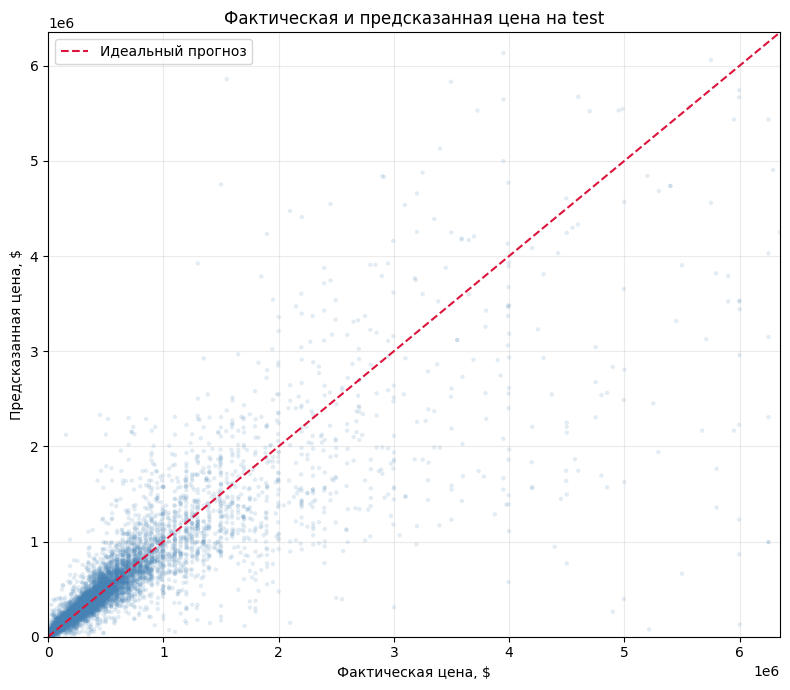

In [109]:
plot_df = test_results.sample(
    n=min(10_000, len(test_results)),
    random_state=RANDOM_STATE
)

plot_limit = (
    test_results[['actual_price', 'predicted_price']]
    .quantile(0.99)
    .max()
)

plt.figure(figsize=(8, 7))

plt.scatter(
    plot_df['actual_price'],
    plot_df['predicted_price'],
    alpha=0.15,
    s=10,
    color='steelblue',
    edgecolors='none'
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    '--',
    color='crimson',
    linewidth=1.5,
    label='Идеальный прогноз'
)

plt.xlim(0, plot_limit)
plt.ylim(0, plot_limit)
plt.xlabel('Фактическая цена, $')
plt.ylabel('Предсказанная цена, $')
plt.title('Фактическая и предсказанная цена на test')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Вывод

На графике видна положительная связь между фактической и предсказанной ценой: более
дорогим объектам в среднем соответствуют более высокие прогнозы.

Разброс точек увеличивается с ростом цены. Это ожидаемо, поскольку абсолютная ошибка
на дорогой недвижимости обычно выше. Ограничение осей 99-м перцентилем позволяет
оценить качество модели на основной части объявлений без влияния редких экстремально
дорогих объектов.

Далее ошибки будут рассмотрены по ценовым сегментам, чтобы проверить, как меняется
качество модели для дешёвых и дорогих объектов.

## Ошибки по ценовым сегментам

Проверим, как качество модели меняется в зависимости от стоимости объекта. Для этого
test-выборка разделяется на пять групп с примерно одинаковым числом наблюдений по
фактической цене.

Отрицательный средний остаток означает, что модель в среднем занижает цену в группе.
Положительный остаток означает завышение.

In [110]:
test_results['price_segment'] = pd.qcut(
    test_results['actual_price'],
    q=5,
    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'],
    duplicates='drop'
)

error_by_segment = (
    test_results
    .groupby('price_segment', observed=True)
    .agg(
        listings=('actual_price', 'size'),
        median_actual_price=('actual_price', 'median'),
        mae=('absolute_error', 'mean'),
        median_ae=('absolute_error', 'median'),
        mean_residual=('residual', 'mean')
    )
    .round(2)
)

display(error_by_segment)

,listings,median_actual_price,mae,median_ae,mean_residual
price_segment,,,,,
Q1,13754,120000.0,36169.67,23471.42,20537.37
Q2,13861,230000.0,39917.36,26726.38,9313.78
Q3,13627,336990.0,60362.99,40458.20,11406.19
Q4,13747,519000.0,116596.13,76084.89,21735.89
Q5,13747,1200000.0,802091.01,284646.71,-487839.57


### Вывод

Абсолютная ошибка растёт вместе со стоимостью объекта. В первых трёх сегментах
медианная ошибка находится в диапазоне от $23,471 до $40,458. В четвёртом сегменте
она увеличивается до $76,085, а в самом дорогом сегменте Q5 — до $284,647.

В сегменте Q5 медианная фактическая цена составляет $1,200,000. Средний остаток равен
\(-$487,840\), то есть модель в среднем занижает стоимость самых дорогих объектов.
В сегментах Q1–Q4 средний остаток положительный, поэтому в них модель в среднем
слегка завышает цену.

Модель лучше подходит для первичной оценки объектов массового ценового сегмента.
Для дорогой и редкой недвижимости её прогноз стоит использовать вместе с экспертной
оценкой.

## Сохранение модели

Сохраним финальную CatBoost-модель и метаданные, необходимые для инференса.

В метаданные входят порядок входных признаков, список категориальных полей,
преобразование целевой переменной и параметры модели. Это позволяет загрузить модель
в отдельном скрипте и использовать её для новых объявлений без повторного обучения.

In [111]:
from pathlib import Path
import joblib

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

MODEL_PATH = ARTIFACTS_DIR / 'catboost_real_estate.cbm'
METADATA_PATH = ARTIFACTS_DIR / 'real_estate_model_metadata.joblib'

final_catboost.save_model(str(MODEL_PATH))

artifact = {
    'feature_columns': X_train_final.columns.tolist(),
    'categorical_features': categorical_features,
    'target_transform': 'log1p',
    'model_type': 'CatBoostRegressor',
    'random_state': RANDOM_STATE,
    'iterations': FINAL_ITERATIONS,
    'model_params': final_catboost.get_params()
}

joblib.dump(artifact, METADATA_PATH)

assert MODEL_PATH.exists(), 'Файл модели не был создан.'
assert METADATA_PATH.exists(), 'Файл метаданных не был создан.'

print(f'Модель сохранена: {MODEL_PATH}')
print(f'Метаданные сохранены: {METADATA_PATH}')

Модель сохранена: artifacts\catboost_real_estate.cbm
Метаданные сохранены: artifacts\real_estate_model_metadata.joblib


In [112]:
def load_real_estate_model(
    model_path: Path,
    metadata_path: Path
) -> tuple[CatBoostRegressor, dict]:
    """Загружает CatBoost-модель и метаданные."""
    if not model_path.exists():
        raise FileNotFoundError(f'Не найден файл модели: {model_path}')

    if not metadata_path.exists():
        raise FileNotFoundError(f'Не найден файл метаданных: {metadata_path}')

    model = CatBoostRegressor()
    model.load_model(str(model_path))

    metadata = joblib.load(metadata_path)

    return model, metadata


def predict_price(
    listing: dict,
    model: CatBoostRegressor,
    metadata: dict
) -> float:
    """Возвращает прогноз цены объекта в долларах."""
    feature_columns = metadata['feature_columns']
    categorical_columns = metadata['categorical_features']

    row = pd.DataFrame([listing])

    missing_features = sorted(
        set(feature_columns) - set(row.columns)
    )

    if missing_features:
        raise ValueError(
            'Не переданы обязательные признаки: '
            + ', '.join(missing_features)
        )

    row = row.reindex(columns=feature_columns)

    for column in categorical_columns:
        row[column] = (
            row[column]
            .fillna('missing')
            .astype(str)
        )

    log_prediction = model.predict(row)[0]

    return float(np.expm1(log_prediction))

In [113]:
loaded_model, loaded_metadata = load_real_estate_model(
    MODEL_PATH,
    METADATA_PATH
)

print('Модель и метаданные успешно загружены.')
print(f'Количество признаков: {len(loaded_metadata["feature_columns"])}')

example_listing = X_test.iloc[0].to_dict()

predicted_price = predict_price(
    listing=example_listing,
    model=loaded_model,
    metadata=loaded_metadata
)

actual_price = float(np.expm1(y_test.iloc[0]))

print(f'Фактическая цена: ${actual_price:,.0f}')
print(f'Прогноз модели: ${predicted_price:,.0f}')
print(f'Абсолютная ошибка: ${abs(actual_price - predicted_price):,.0f}')

Модель и метаданные успешно загружены.
Количество признаков: 13
Фактическая цена: $2,395,000
Прогноз модели: $2,725,921
Абсолютная ошибка: $330,921


## Итоговый вывод

В работе построена модель `CatBoostRegressor` для первичной оценки стоимости жилой
недвижимости по характеристикам объекта, типу жилья и географическим признакам.

Перед обучением были удалены полные дубликаты, исключены объявления об аренде и
земельные участки, а текстовые признаки были преобразованы в числовые и категориальные.
Для проверки различий между типами недвижимости использовался критерий Kruskal–Wallis.
Разделение данных выполнено с помощью `GroupShuffleSplit`, поэтому повторные объявления
одного объекта не попадают одновременно в train, validation и test.

Целевая переменная преобразована с помощью `log1p(price)`, чтобы уменьшить влияние
редких дорогих объектов. На validation CatBoost превзошёл медианный baseline и
Ridge-регрессию, поэтому был выбран финальной моделью. После выбора конфигурации модель
обучена на объединённых train и validation данных, а test использовался только для
финальной оценки.

На test-выборке из 68,736 объявлений получены следующие результаты:

- MAE: $210,989
- Медианная абсолютная ошибка: $48,078
- RMSE: $1,151,865
- \(R^2\) в денежной шкале: 0.646
- `log_RMSE`: 0.418
- \(R^2\) для `log_price`: 0.844

Модель лучше работает на объектах массового ценового сегмента. В первых трёх ценовых
квинтилях медианная абсолютная ошибка составляет от $23,471 до $40,458. Для 20% самых
дорогих объектов она возрастает до $284,647, а средний остаток равен \(-$487,840\).
Это означает, что в премиальном сегменте модель в среднем занижает цену.

Итоговую модель можно использовать для быстрой ориентировочной оценки объектов в
формате исходного датасета. Для дорогой, редкой недвижимости и объявлений с
незаполненными характеристиками прогноз следует использовать вместе с экспертной
оценкой.

Модель сохранена в `artifacts/catboost_real_estate.cbm`, а метаданные для инференса —
в `artifacts/real_estate_model_metadata.joblib`.